### The goal of this notebook is to reanalyze the datasets that we worked with over the summer to check if the kolmogorov scales are resolved (shocker they're not). Then, we need to come up with anew method to resolve the smallest scales

We want to calculate the smallest $ \eta $ for our experiments to see if it is smaller than our grid cell size $ \Delta x, \Delta z $

In [1]:
#import packages

using Oceananigans
using CairoMakie
using NCDatasets
using Statistics
using Printf
using LsqFit

In [ ]:
#import datasets we need the oceanostics file for the dissipation rate
# we will analyze the 1e5, 1e6, and 1e7 Ra cases with hill

#these are the files i used over the summer with my OLD method of resolving the kolmogorov scales

ds_1 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_2 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_4 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

ds_list = [ds_1, ds_2, ds_3, ds_4];


In [3]:
#define the grid cell sizes Δz is always gonna be larger than Δx so we only need to check Δx
Lx = ds_1.attrib["Lx"]
H = ds_1.attrib["H"]

Δx_1 = Lx/169
Δx_2 = Lx/301
Δx_3 = Lx/450
Δx_4 = Lx/535;


Δxs = [Δx_1, Δx_2, Δx_3, Δx_4];

In [31]:
Δzs = []
for ds in ds_list
    z = ds["zC"][4+1:end-4]
    delta_z = z[2] - z[1]
    push!(Δzs, delta_z)
end

In [34]:
#ε_1 = ds_1["ε"][4+1:end-4, 1, 4+1:end-4, :]
#ε_2 = ds_2["ε"][4+1:end-4, 1, 4+1:end-4, :]
#ε_3 = ds_3["ε"][4+1:end-4, 1, 4+1:end-4, :]
#ε_4 = ds_4["ε"][4+1:end-4, 1, 4+1:end-4, :];

epsilons = []
nus = []

for ds in ds_list
    ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
    ν = ds.attrib["ν"]
    push!(epsilons, ε)
    push!(nus, ν)
end

function get_η(ε, ν)
    η = (ν^3 ./ ε) .^ (1/4)
    return η
end

eta_mins = []
for (ε, ν) in zip(epsilons, nus)
    η = get_η(ε, ν)
    push!(eta_mins, minimum(x for x in η if x > 0))
end

### When do the smallest eddies exist? When do they equilibrate?

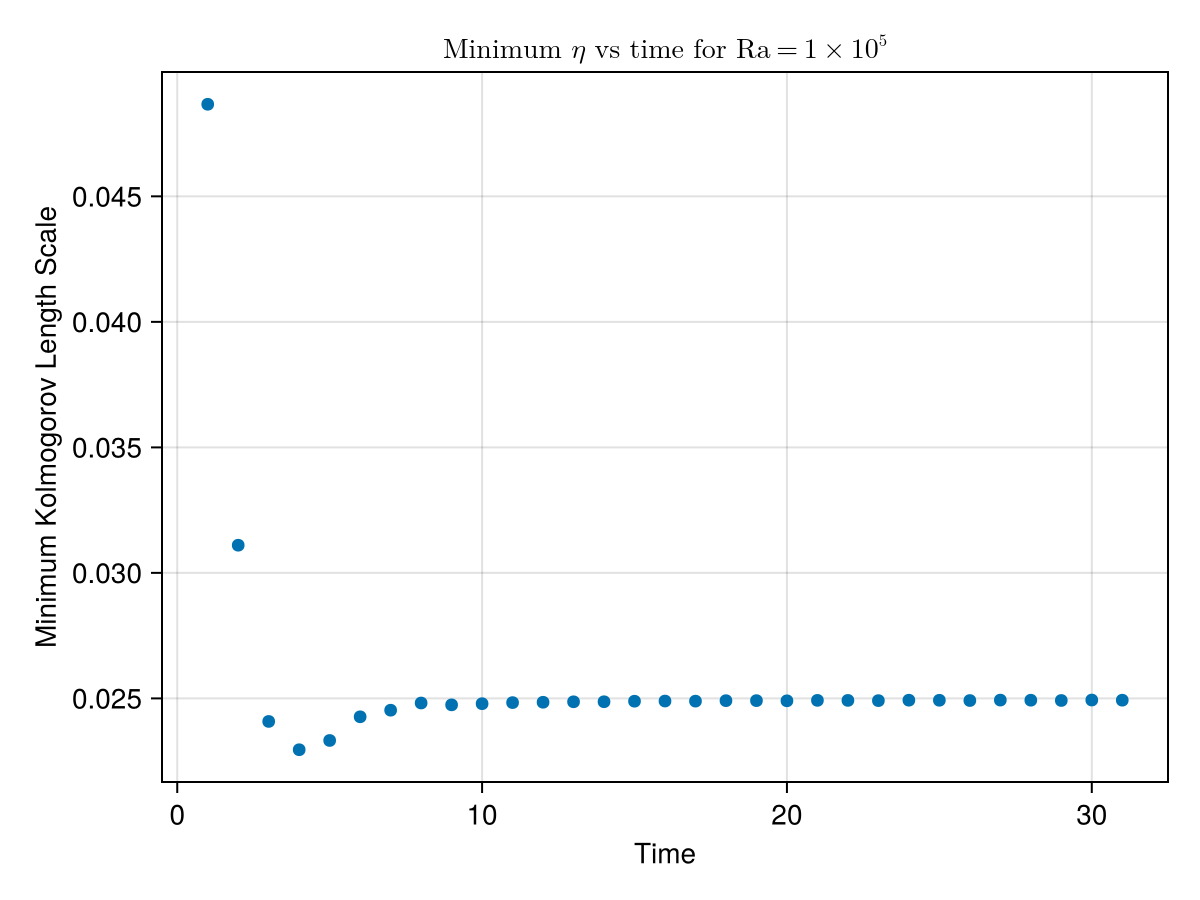

In [35]:
η_mins_vs_time = minimum(get_η(epsilons[1], nus[1]), dims=(1,2))[1,1,2:end];

f = Figure()
ax = Axis(f[1,1], xlabel="Time", ylabel="Minimum Kolmogorov Length Scale", title=L"\text{Minimum } \eta \text{ vs time for Ra=} 1\times10^5")
plot!(ax, η_mins_vs_time)
f
#average eta over the equilibrium time is the length scale that we need to resolve

In [36]:
function is_kolmogorov_resolved(Δx, ε, ν)
    η = get_η(ε, ν)
    η_min = minimum(x for x in η if x > 0)
    if Δx < η_min
        return true, η_min
    else
        return false, η_min
    end
end

for (i,j,k) in zip(epsilons, Δxs, nus)
    resolved, η_min = is_kolmogorov_resolved(j, i, k)
    if resolved
        @printf("The Kolmogorov scale is resolved with Δx = %.5f and η_min = %.5f\n", j, η_min)
    else
        @printf("The Kolmogorov scale is NOT resolved with Δx = %.5f and η_min = %.5f\n", j, η_min)
    end
end

The Kolmogorov scale is NOT resolved with Δx = 0.04734 and η_min = 0.02295
The Kolmogorov scale is NOT resolved with Δx = 0.02658 and η_min = 0.00855
The Kolmogorov scale is NOT resolved with Δx = 0.01778 and η_min = 0.00424
The Kolmogorov scale is NOT resolved with Δx = 0.01495 and η_min = 0.00279


### How does the size of the smallest eddy change as the grid scaling gets finer?

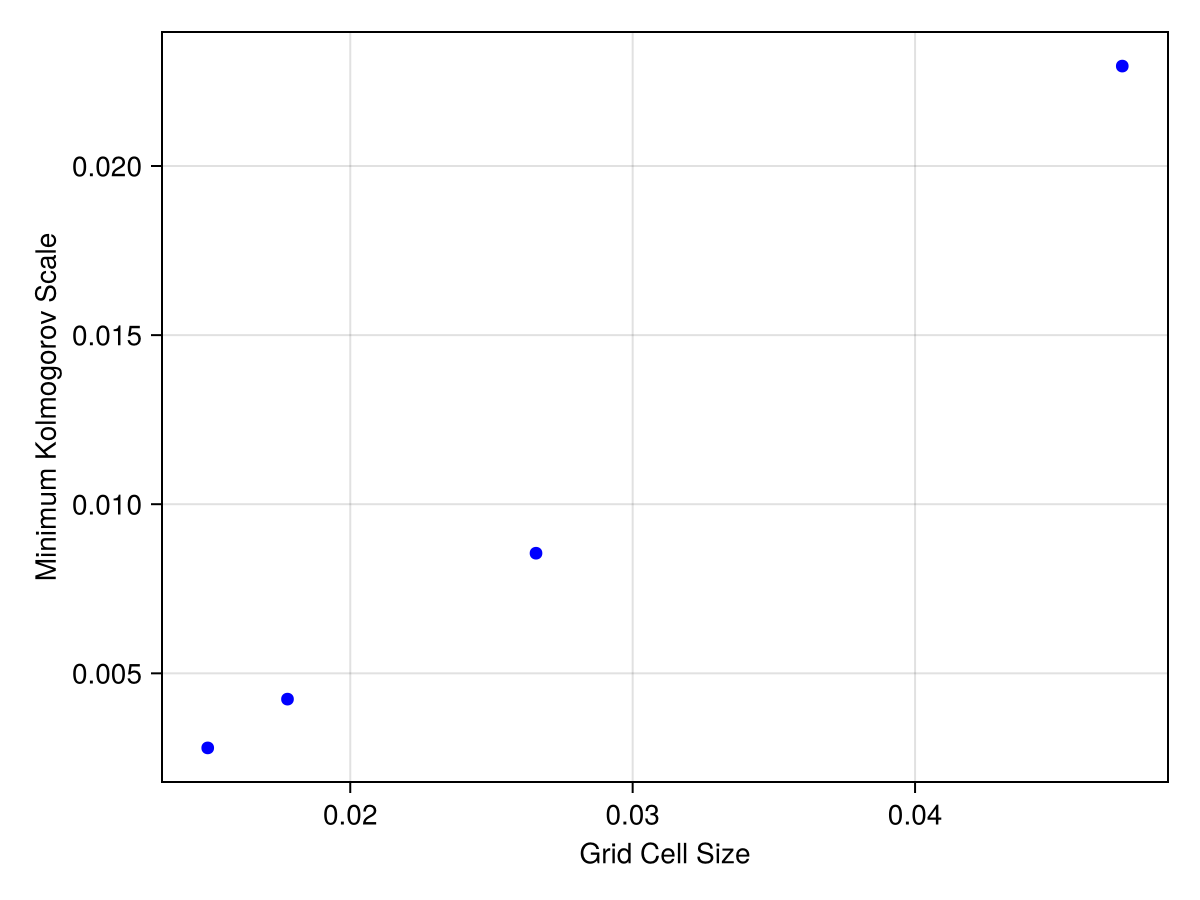

In [38]:
fig = Figure()
ax = Axis(fig[1,1], xlabel="Grid Cell Size", ylabel ="Minimum Kolmogorov Scale")
scatter!(ax, Δxs, eta_mins, color=:blue)

fig

the size of the smallest eddie increases as the grid scaling gets 

### Now we want to calculate the ratio $r(x,t) = \frac{\Delta x}{\eta(x,t)}$
from this we can see if the dissipative scales are resolved

if $r <<1 $ the dissipative scales are well resolved

if $ r \geq 1 $ the smallest dissipative structures are under-resolved

In [9]:
function get_ratio(Δx, ε, ν)
    η = get_η(ε, ν)
    η_data = filter(x -> isfinite(x) && x > 0, vec(η))
    r = Δx ./ η_data
    return r
end

r_maxes = []
for (Δx, ε, ν) in zip(Δxs, epsilons, nus)
    r = get_ratio(Δx, ε, ν)
    push!(r_maxes, maximum(r))
end

function compute_statistics(Δx, ε, ν)
    r = get_ratio(Δx, ε, ν)

    r_min = minimum(r)
    r_max = maximum(r)
    r_median = median(r)
    r_mean = mean(r)
    r_95 = quantile(r, 0.95)

    frac_r_greater_than_1 = count(>(1.0), r) / length(r)

    return Dict(
        "r_min" => r_min,
        "r_max" => r_max,
        "r_median" => r_median,
        "r_mean" => r_mean,
        "r_95" => r_95,
        "frac_r_greater_than_1" => frac_r_greater_than_1
    )
end

compute_statistics (generic function with 1 method)

In [10]:
#statistics for Ra = 1e5
compute_statistics(Δx_1, epsilons[1], nus[1])

Dict{String, Float64} with 6 entries:
  "r_max"                 => 2.06219
  "r_mean"                => 0.630335
  "r_95"                  => 1.07177
  "r_median"              => 0.614233
  "frac_r_greater_than_1" => 0.0778614
  "r_min"                 => 0.0292255

In [12]:
#statistics for Ra = 1e6
compute_statistics(Δx_2, epsilons[2], nus[2])

Dict{String, Float64} with 6 entries:
  "r_max"                 => 3.10807
  "r_mean"                => 0.529739
  "r_95"                  => 1.10921
  "r_median"              => 0.476319
  "frac_r_greater_than_1" => 0.0699433
  "r_min"                 => 0.0135689

In [13]:
#statistics for Ra = 5e6
compute_statistics(Δx_3, epsilons[3], nus[3])

Dict{String, Float64} with 6 entries:
  "r_max"                 => 4.19588
  "r_mean"                => 0.507795
  "r_95"                  => 1.09068
  "r_median"              => 0.440018
  "frac_r_greater_than_1" => 0.0824417
  "r_min"                 => 0.00145152

In [14]:
#statistics for Ra = 1e7
compute_statistics(Δx_4, epsilons[4], nus[4])

Dict{String, Float64} with 6 entries:
  "r_max"                 => 5.35069
  "r_mean"                => 0.499282
  "r_95"                  => 1.08622
  "r_median"              => 0.414368
  "frac_r_greater_than_1" => 0.0872116
  "r_min"                 => 0.00132029

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie /Users/hfdrake/.julia/packages/Makie/rEu75/src/scenes.jl:227


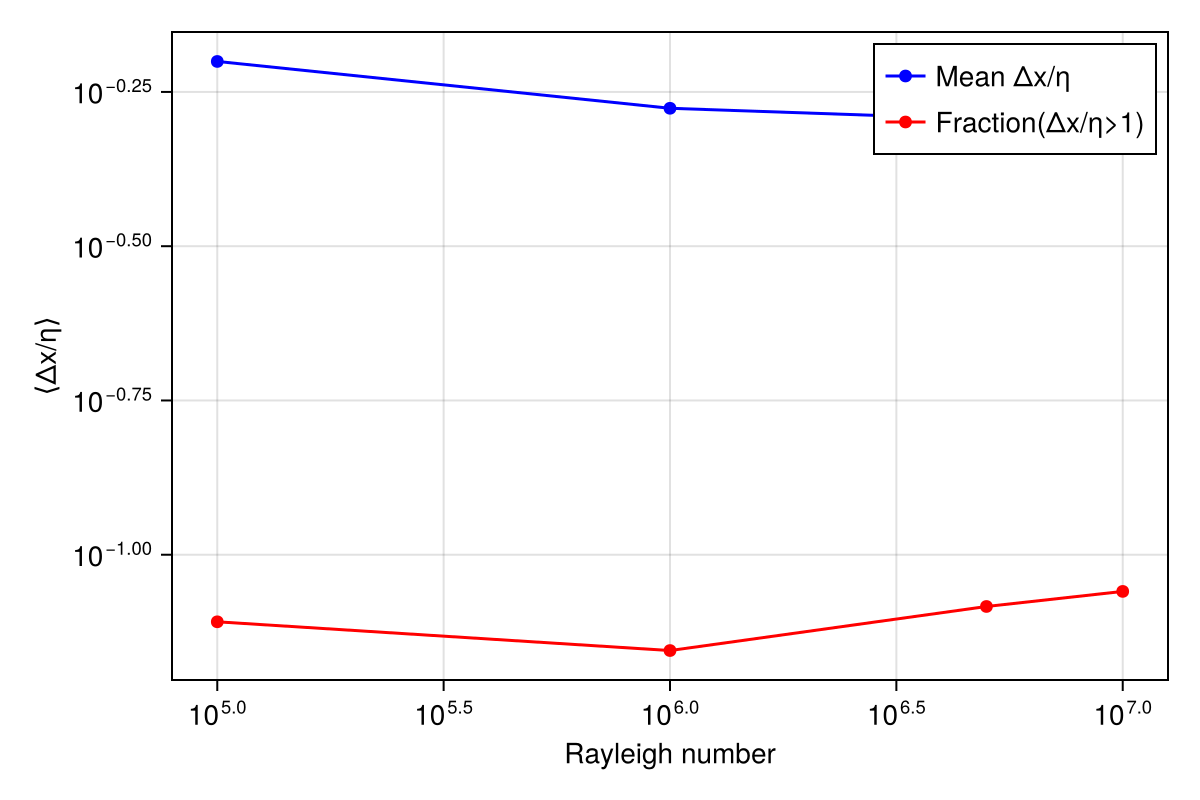

In [20]:
Ras = [1e5, 1e6, 5e6, 1e7]
r_mean = [0.630, 0.529, 0.5078, 0.4999]  
frac_r_gt1 = [0.0778614, 0.0699433, 0.0824417, 0.0872116]

f = Figure(resolution=(600,400))
ax = Axis(f[1,1], xscale=log10, yscale=log10,
          xlabel="Rayleigh number", ylabel="⟨Δx/η⟩")

scatterlines!(ax, Ras, r_mean, color=:blue, label="Mean Δx/η")
scatterlines!(ax, Ras, frac_r_gt1, color=:red, label="Fraction(Δx/η>1)")
axislegend(ax)
f


The fitted model is Δx/η_min = 0.16735 * Ra ^ 0.21262


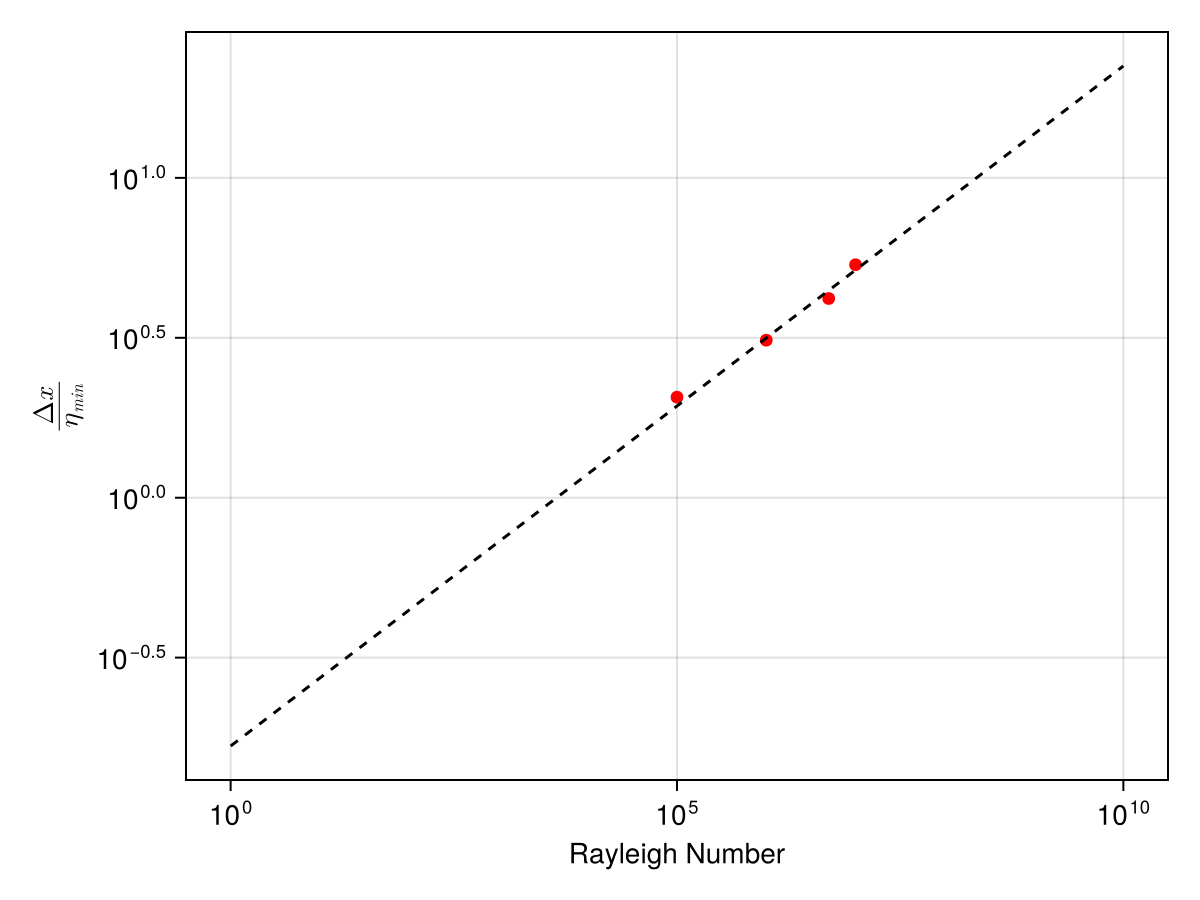

In [19]:
model(x,p) = p[1] .* x .^ p[2]
x = [1e5, 1e6, 5e6, 1e7]
y = r_maxes
p0 = [1.0, 0.0] # Initial guess for parameters

fit = curve_fit(model, x, y, p0)
a,b = fit.param
@printf("The fitted model is Δx/η_min = %.5f * Ra ^ %.5f\n", a, b)
xfit= range(1, stop=1e10, length=200)
yfit = model(xfit, fit.param)

fig2 = Figure()
ax2 = Axis(fig2[1,1], xlabel="Rayleigh Number", ylabel =L"$\frac{Δx}{η_{min}}$", xscale=log10, yscale=log10)
scatter!(ax2, [1e5, 1e6, 5e6, 1e7], r_maxes, color=:red)
lines!(ax2, xfit, yfit, color=:black, linestyle=:dash)
#lines!(ax2, xfit, ones(200))

fig2


#### so we have found a function relating $r_{max} = \frac{\Delta x}{\eta_{min}} $ to the rayleigh number :$$ r_{max} = \frac{\Delta x }{\eta_{min}} = 0.16735 * Ra^{0.21262} $$

if we rearrange this, substituting $\Delta x = \frac{L_x}{N_x}$ in order to create a function that gives us the new resolution, given the smallest kolmogorov length scale. This gives us: $$ N_x = \frac{L_x}{\eta_{min}} (0.16735 * Ra^{0.21262})^{-1} $$ 

Similarly, for the z resolution : 

$$ N_z = \frac{H}{\eta_{min}} (0.16735 * Ra^{0.21262})^{-1} $$

In [48]:
function KolmogorovResolution(Ra, η_min)
    Lx = 8.0
    H = 1.0
    a = 0.16735
    b = 0.21262
    c = 0.5
    Nx = (Lx/(η_min)) * (a * Ra ^(b))^(-1)
    Nz = (H/(η_min)) * (a * Ra^(b))^(-1)

    Δx = Lx/Nx
    Δz = H/Nz

    return Nx, Nz, η_min, Δx

end

Ras = [1e5, 1e6, 5e6, 1e7]
#Nx, H, eta_mins all defined earlier

for (r, e) in zip(Ras, eta_mins)
    println("The Kolmogorov Resolution is ", KolmogorovResolution(r, e))
end


The Kolmogorov Resolution is (180.0904499418026, 22.511306242725325, 0.022954803909297473, 0.04442212234232994)
The Kolmogorov Resolution is (296.2862391473257, 37.035779893415715, 0.0085513127224135, 0.027000916488808212)
The Kolmogorov Resolution is (424.69275548572557, 53.086594435715696, 0.004236960500113376, 0.018837147318066013)
The Kolmogorov Resolution is (555.6454814737145, 69.45568518421432, 0.0027946439409090515, 0.014397669497431969)


##### This doesn't work. my intuition is super wrong. lets try a diff function. here we will use the $\eta_{min}$ and set $\Delta x$ to that and work backwards. 

### lets repeat this for $\eta_{min}$ we expect to have a similar function

The fitted model is η_min = 3.50792 * Ra ^ -0.43673


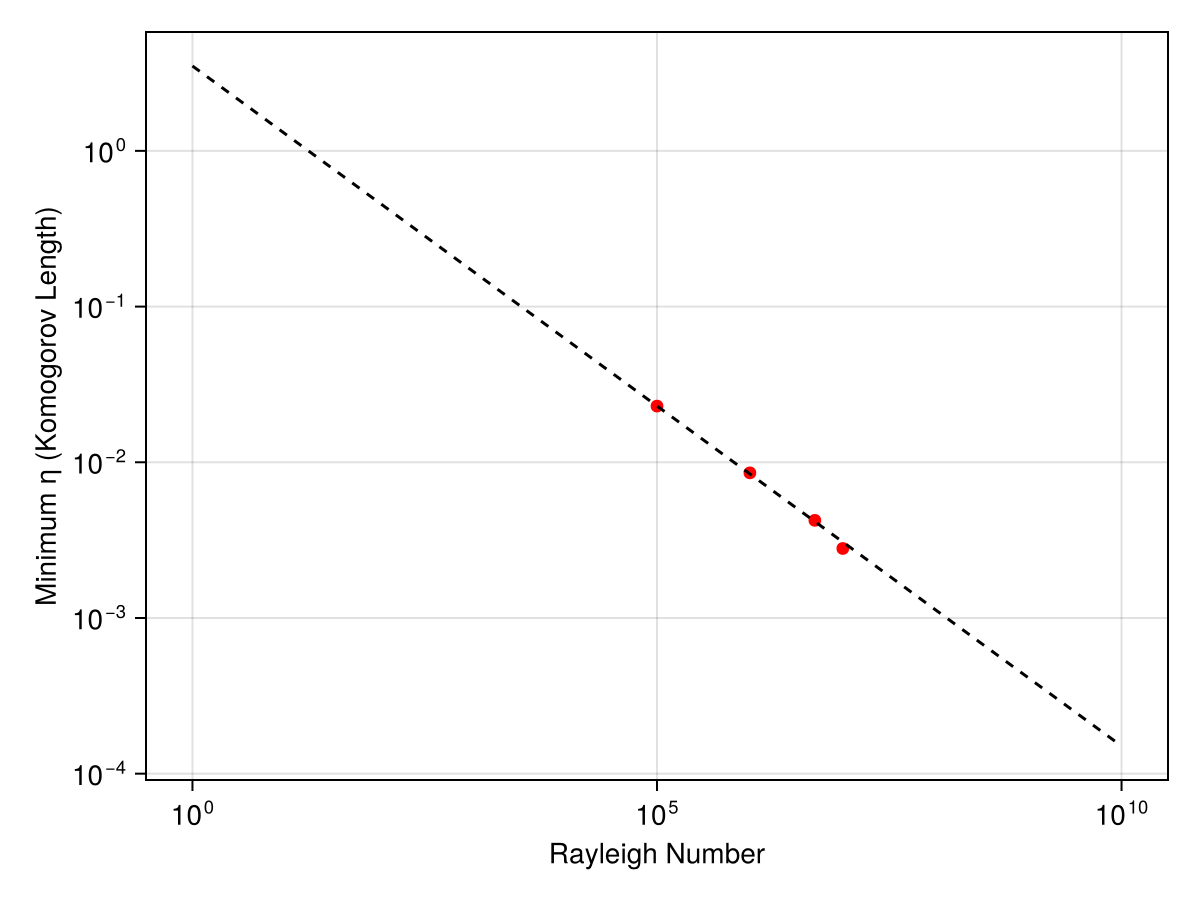

In [49]:
min_eta_model(x,p) = p[1] .* x .^ p[2]
x = [1e5, 1e6, 5e6, 1e7]
y = eta_mins
p0 = [1.0, 0.0] # Initial guess for parameters

fit = curve_fit(model, x, y, p0)
a,b = fit.param
@printf("The fitted model is η_min = %.5f * Ra ^ %.5f\n", a, b)
xfit= range(1, stop=1e10, length=200)
yfit = model(xfit, fit.param)

fig2 = Figure()
ax2 = Axis(fig2[1,1], xlabel="Rayleigh Number", ylabel ="Minimum η (Komogorov Length)", xscale=log10, yscale=log10)
scatter!(ax2, [1e5, 1e6, 5e6, 1e7], eta_mins, color=:red)
lines!(ax2, xfit, yfit, color=:black, linestyle=:dash)

fig2

### Okay so now we have a function relating the SMALLEST eddies to the Rayleigh number of the simulation. and we can use this to extrapolate what the minimum kolmogorov scale that we need to resolve for future higher Ra simulations.

What we will do is set a guess value for $\Delta x $ and $\Delta z$ ensuring that it is SMALLER than the kolmogorov scale. I will actually set it as  $\Delta x = 0.8 * \eta_{min}$ to be safe. Then we work backwards to get $Nx$ and $Nz$. 

In [64]:
function Kolmo2(Ra)
    Lx = 8.0
    H = 1.0
    a = 3.50792
    b = -0.43673
    c = 0.5
    η_min = a * Ra^(b)
    gridcell = c * η_min #delta x and delta z are equilvalent and MUST be smaller than η_min
    Nx = Lx / gridcell
    Nz = H / gridcell

    return Nx, Nz
end

for r in Ras
    @printf("The kolmogorov resolution for Ra = %.5f is Nx = %.5f, Nz = %0.5f\n", r, Kolmo2(r)[1], Kolmo2(r)[2])
end


The kolmogorov resolution for Ra = 100000.00000 is Nx = 696.17801, Nz = 87.02225
The kolmogorov resolution for Ra = 1000000.00000 is Nx = 1903.05045, Nz = 237.88131
The kolmogorov resolution for Ra = 5000000.00000 is Nx = 3843.36360, Nz = 480.42045
The kolmogorov resolution for Ra = 10000000.00000 is Nx = 5202.11923, Nz = 650.26490


### OKAY!!!!! Now we know what resolution we *really* need ... and shocker its MUCH MUCH higher than what we were currently running at. 

In [22]:
println("the kolmogorov res for a Ra=1e11 simulation is", Kolmo2(1e11))

the kolmogorov res for a Ra=1e11 simulation is(181543.3392732628, 22692.91740915785, 5.508326573715708e-5, 4.4066612589725665e-5)


ummmm yeah so like i dont know if i'll ever be able to run a TRUE DNS at such high Rayleigh numbers 

lets see what the resolution for the real ocean would have to be 

In [71]:
# resolution of the real ocean some fuck ass calculation lol

ε_ocean = 1e-9
H_ocean = 4 * 10^3 #meters (depth scale)
L_ocean = 14000 * 10^3 #meters (meridional scale)
Ra_ocean = 1e21
ν_ocean = 1e-6 

η_ocean = get_η(ε_ocean, ν_ocean)
grid_ocean = 0.5 * η_ocean
Nx_ocean = L_ocean / grid_ocean
Nz_ocean = H_ocean / grid_ocean

@printf("Resolution of the ocean is Nx = %.5f, Nz = %.5f", Nx_ocean, Nz_ocean)

η_ocean

Resolution of the ocean is Nx = 4979182348.10898, Nz = 1422623.52803

0.005623413251903491

### I ran a Ra=1e5 simulation with "true" kolmo resolution, lets checked if it's resolved

In [23]:
ds_5_new = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/NEWresolved/turbulent_onehill_0.6_Ra100000.0_coldstart/oceanostics.nc"));
ε_res_new = ds_5_new["ε"][4+1:end-4, 1, 4+1:end-4, :]
ν_res_new = ds_5_new.attrib["ν"]
η_res_new = get_η(ε_res_new, ν_res_new)
η_min_res_new = minimum(x for x in η_res_new if x > 0)

Δx_new = ds_5_new.attrib["Lx"]/435

if Δx_new < η_min_res_new
    @printf("The Kolmogorov scale is resolved for Ra = 1e5 with Δx = %.5f and η_min = %.5f\n", Δx_new, η_min_res_new)
else
    @printf("The Kolmogorov scale is NOT resolved for Ra = 1e5 with Δx = %.5f and η_min = %.5f\n", Δx_new, η_min_res_new)
end


The Kolmogorov scale is NOT resolved for Ra = 1e5 with Δx = 0.01839 and η_min = 0.01549


In [27]:
compute_statistics(Δx_new, ε_res_new, ν_res_new)

Dict{String, Float64} with 6 entries:
  "r_max"                 => 1.18757
  "r_mean"                => 0.240118
  "r_95"                  => 0.417262
  "r_median"              => 0.234207
  "frac_r_greater_than_1" => 6.5801e-7
  "r_min"                 => 0.00189757

### OKAY!!!!! Much closer!

In [74]:
using TopographicHorizontalConvection:dissipation_analysis

In [76]:
constraint_1, ε_1_avg, ε_1_mean = dissipation_analysis(ds_1, "ε");

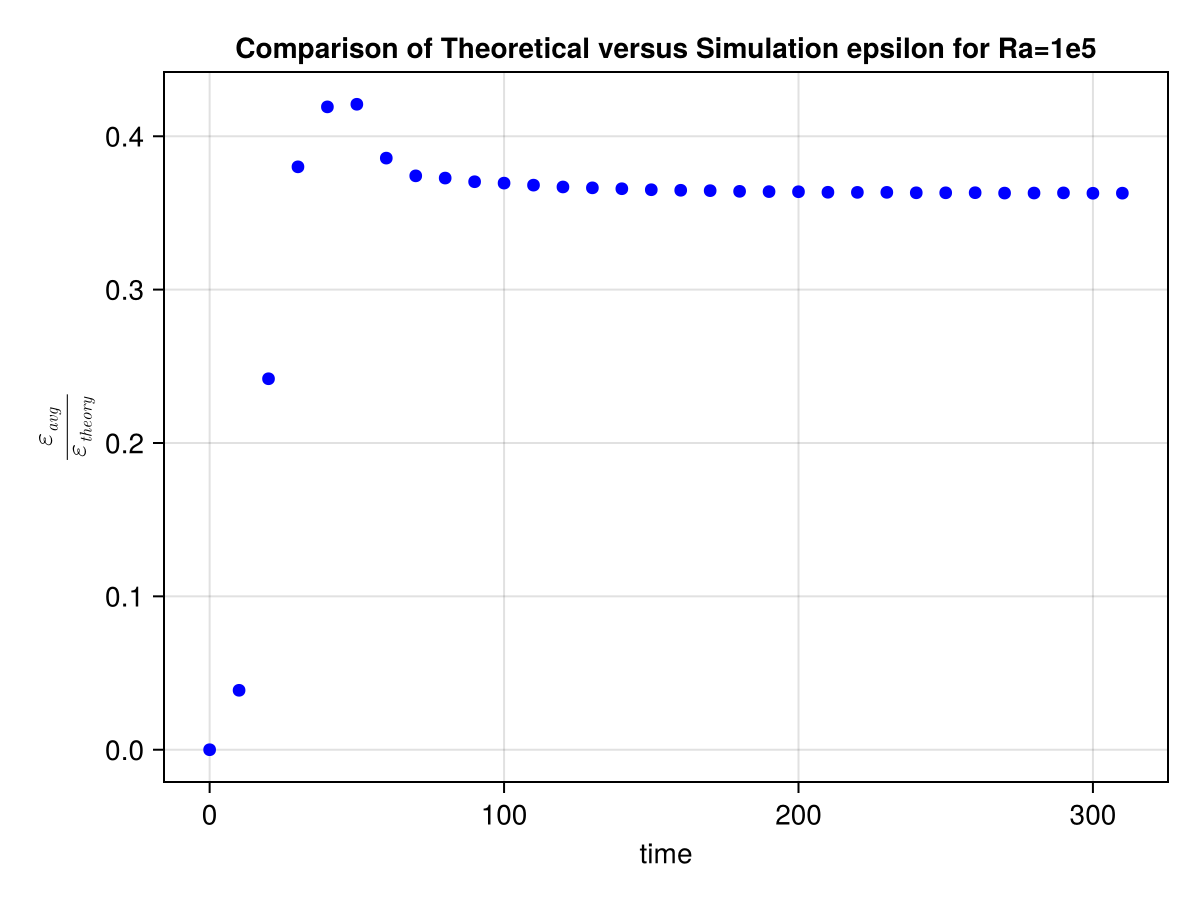

In [ ]:
f = Figure()
ax = Axis(f[1, 1], xlabel = "time", ylabel = L"\frac{\varepsilon_{avg}}{\varepsilon_{theory}}", title = "Comparison of Theoretical versus Simulation epsilon for Ra=1e5")
plot!(ax, ds_1["time"], ε_1_avg ./ constraint_1, color = :blue)

f

Now, lets compare some simulations where the kolmogorov res is most definitely not resolved to show that resolving the smallest scales is important to understanding the physics. 

In [18]:
ds_nr_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/notresolved/turbulent_onehill_0.6_Ra1.0e7_coldstart/oceanostics.nc"));
ds_nr_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/notresolved/turbulent_onehill_0.6_Ra1.0e7_coldstart/buoyancy.nc"));
ds_nr_vel = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/notresolved/turbulent_onehill_0.6_Ra1.0e7_coldstart/velocities.nc"));

In [19]:
ds_4 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));
ds_4_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));
ds_4_vel = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_velocities.nc"));


In [ ]:
#calculate ratio for not resolved similarly
Δx = 8/256


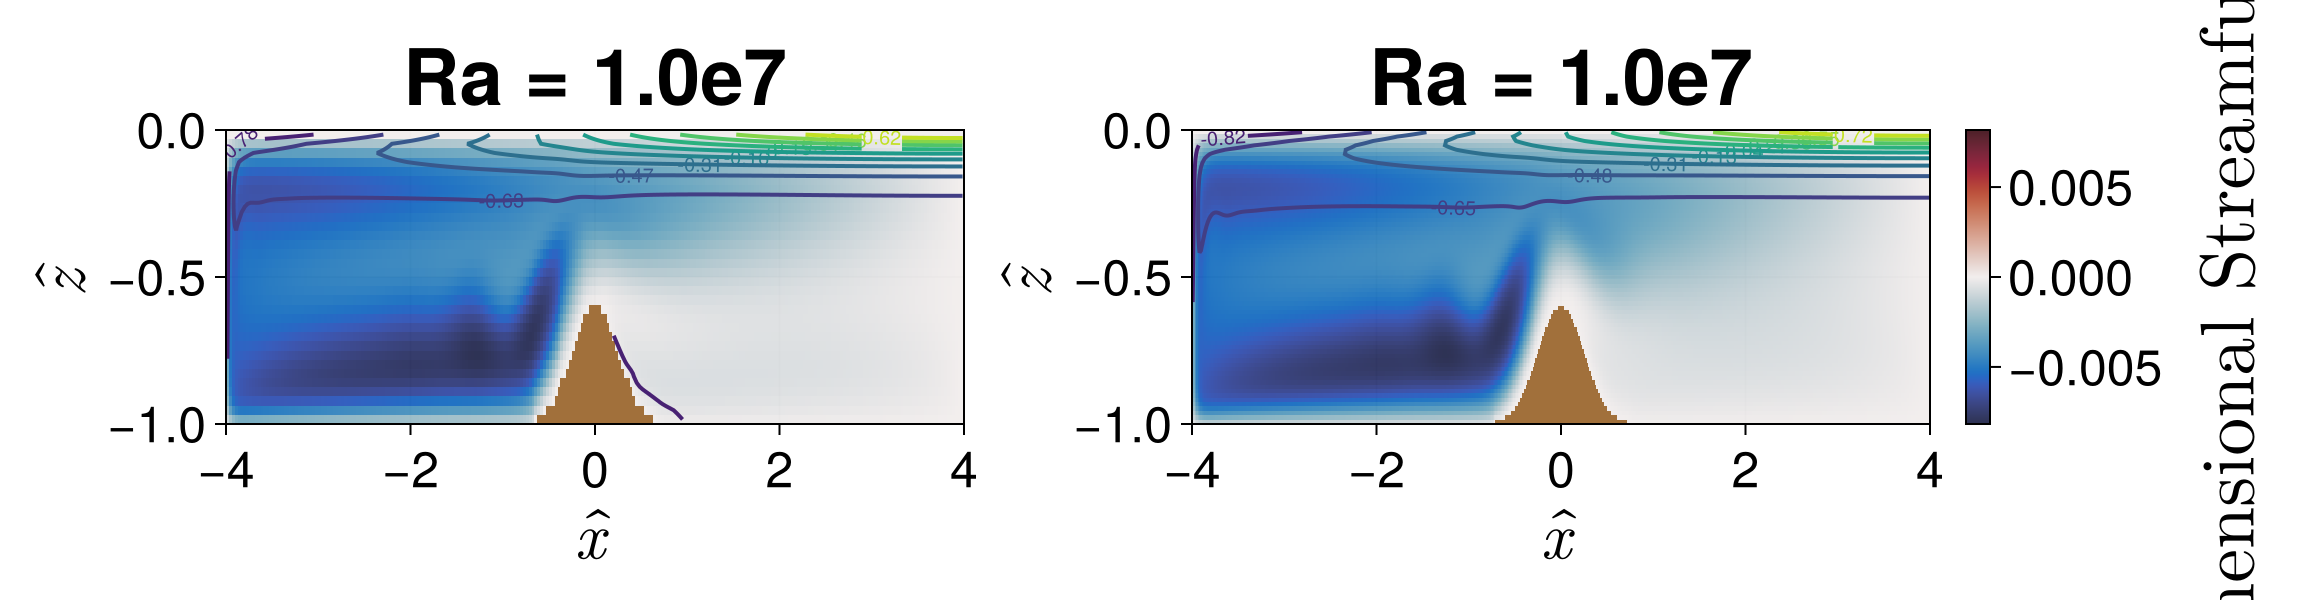

In [20]:
using TopographicHorizontalConvection:streamfunction_subplots
fig_streamfunction_comparison = streamfunction_subplots([ds_nr_b, ds_4_b], [ds_nr_vel, ds_4_vel])

1.5442168252124562-Inf2.1107484641555776-Inf

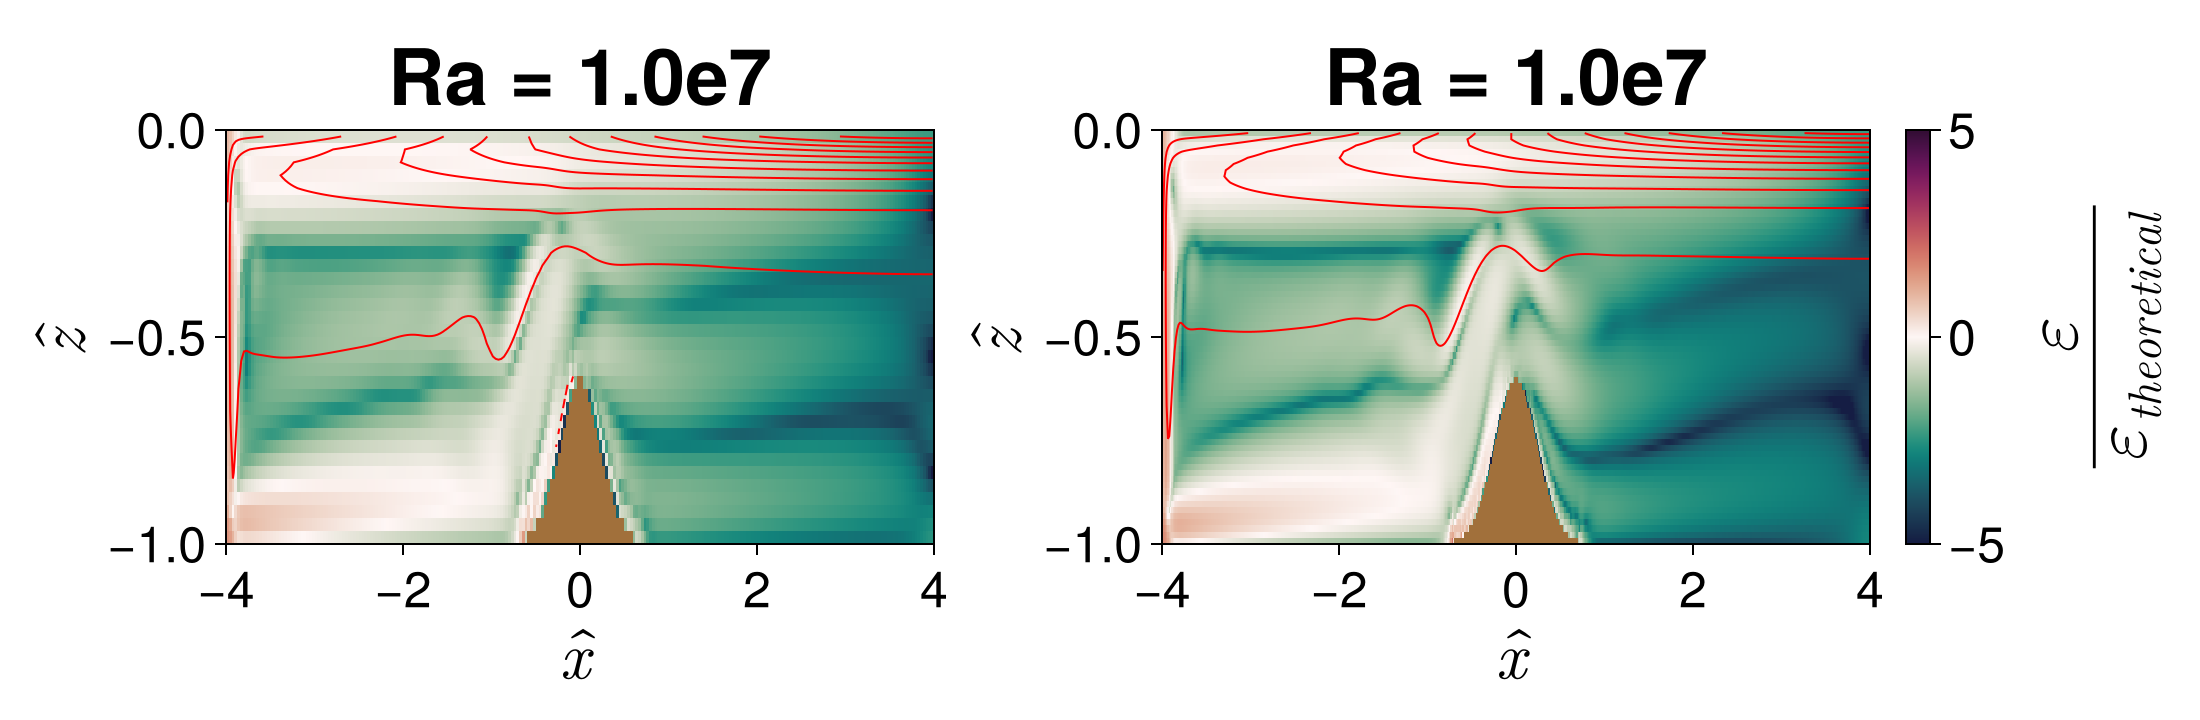

In [22]:
using TopographicHorizontalConvection:diss_norm_eq_subplots
epsilon_compare = diss_norm_eq_subplots([ds_nr_o, ds_4], [ds_nr_b, ds_4_b], "ε", (-5, 5))

-1.1091571607863373-Inf-1.0893255032419924-Inf

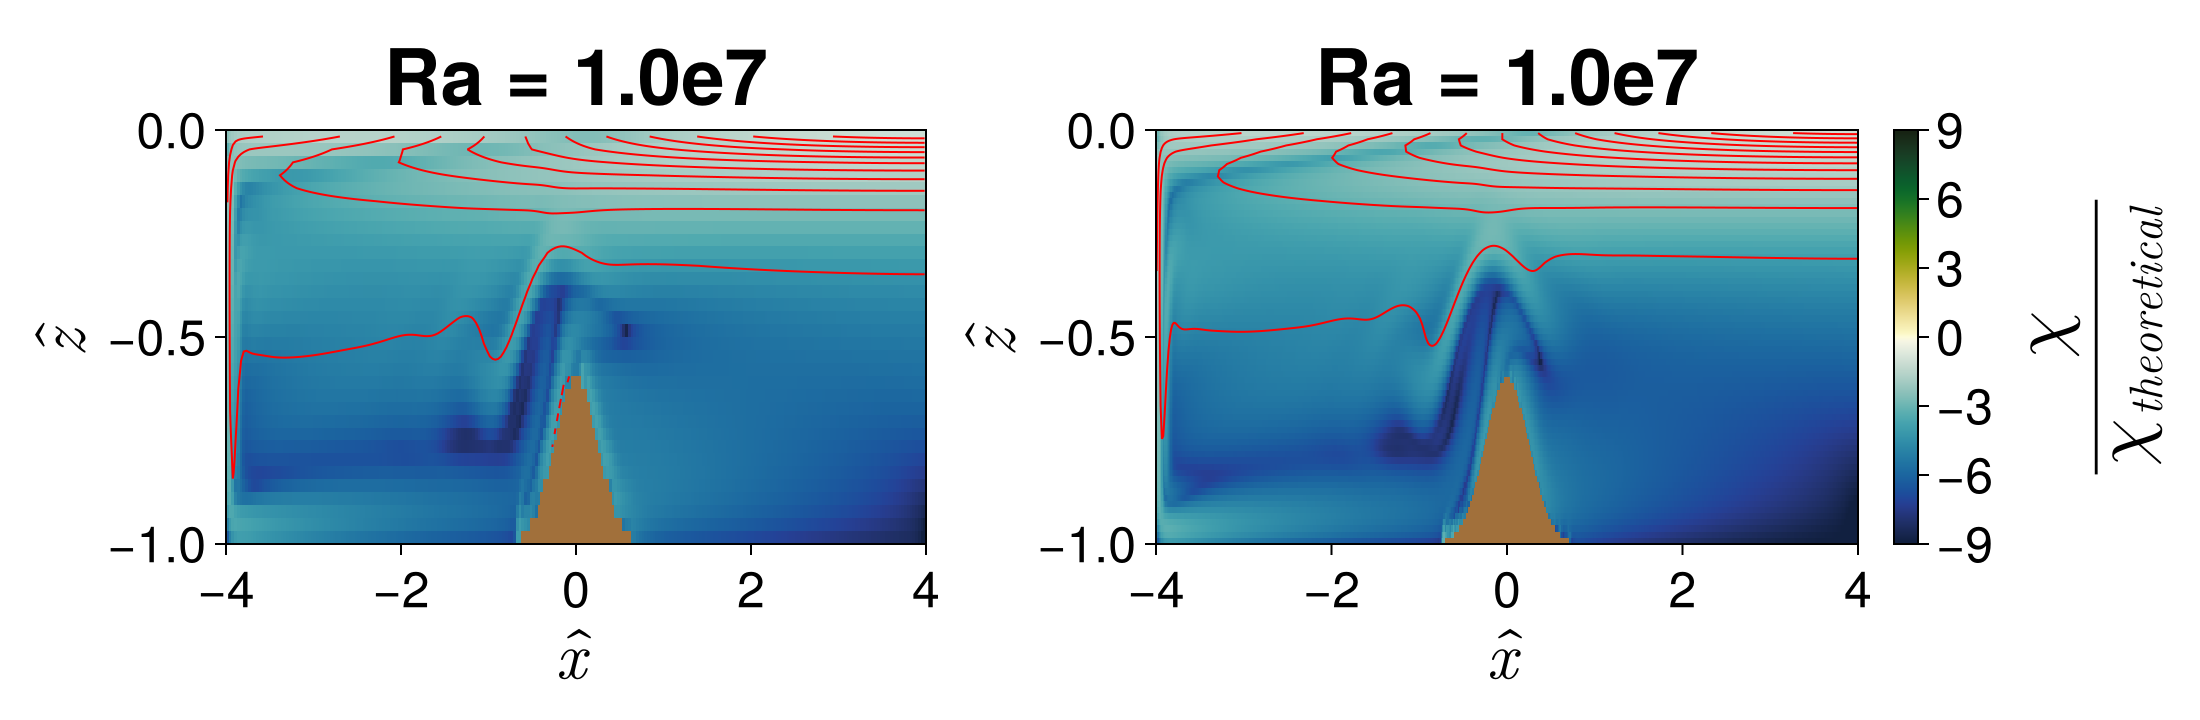

In [25]:
chi_compare = diss_norm_eq_subplots([ds_nr_o, ds_4], [ds_nr_b, ds_4_b], "χ", (-9, 9))

[200000.0, 2.0e6, 1.0e7, 2.0e7]

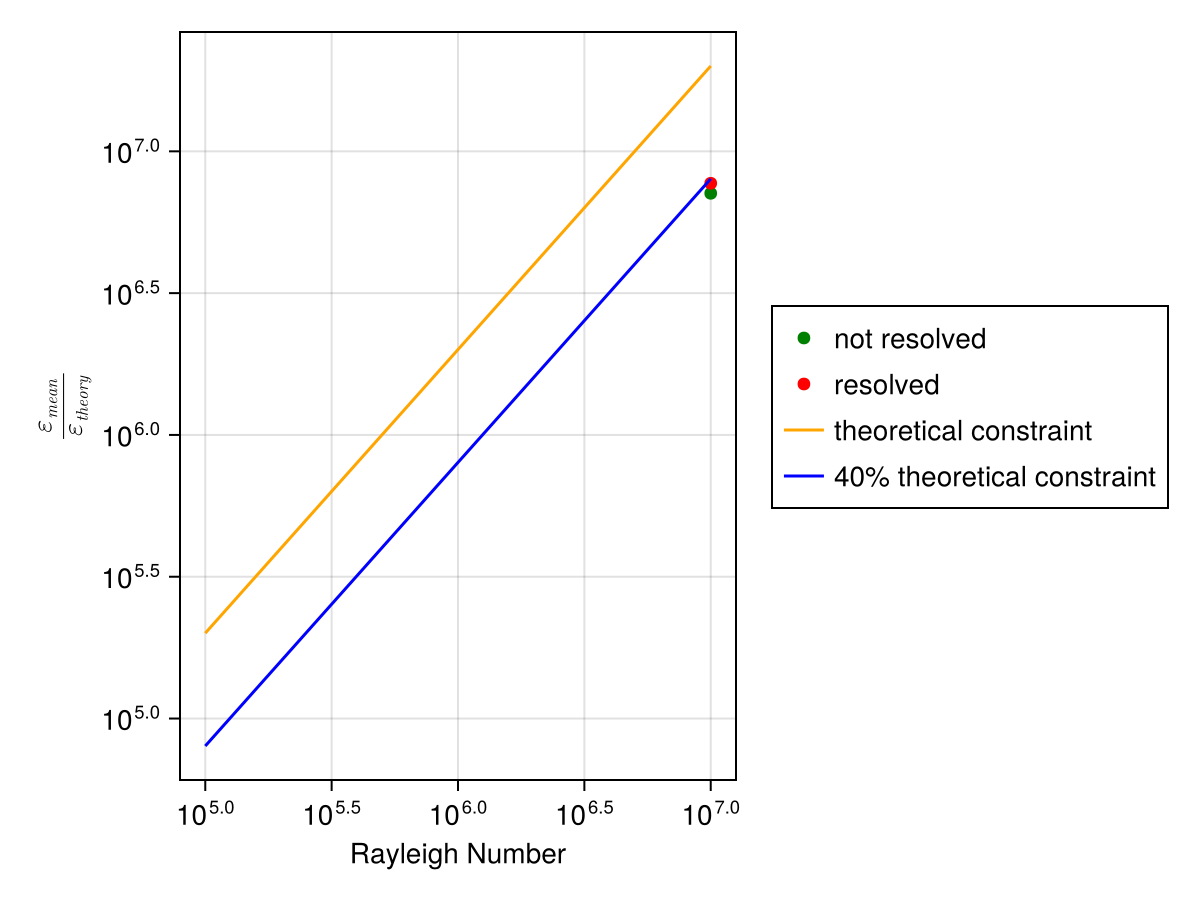

In [56]:
using TopographicHorizontalConvection:dissipation_analysis

Ras = [1e5, 1e6, 5e6, 1e7]
ε_means = []
χ_means = []
χ_theories_from_brain = 4.57 .* 2^(7/3) .* Ras.^(7/3)
ε_theories_from_brain = 2 .* Ras
print(ε_theories_from_brain)

for ds in [ds_nr_o, ds_4]
    ν = ds.attrib["ν"]
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    e_time_mean = dissipation_analysis(ds, "ε")[3] ./ (ν^3 / H^4)
    chi_time_mean = dissipation_analysis(ds, "χ")[3] ./ (κ^5 / H^8)

    push!(ε_means, e_time_mean)
    push!(χ_means, chi_time_mean)

end
f_ε = Figure()
ax = Axis(f_ε[1,1],
            xscale = log10,
            yscale = log10, 
            xlabel = "Rayleigh Number",
            ylabel = L"\frac{\varepsilon_{mean}}{\varepsilon_{theory}}"
)


scatter!(ax, 1e7, ε_means[1], label="not resolved", color= :green)
scatter!(ax, 1e7, ε_means[2], color = :red, label="resolved")
lines!(ax, Ras, ε_theories_from_brain, color = :orange, label="theoretical constraint")
lines!(ax, Ras, ε_theories_from_brain * 0.4, color = :blue, label="40% theoretical constraint")
Legend(f_ε[1,2], ax)

f_ε

In [60]:
χ_means

2-element Vector{Any}:
 1.2525965891035512e15
 1.2418314793695178e15

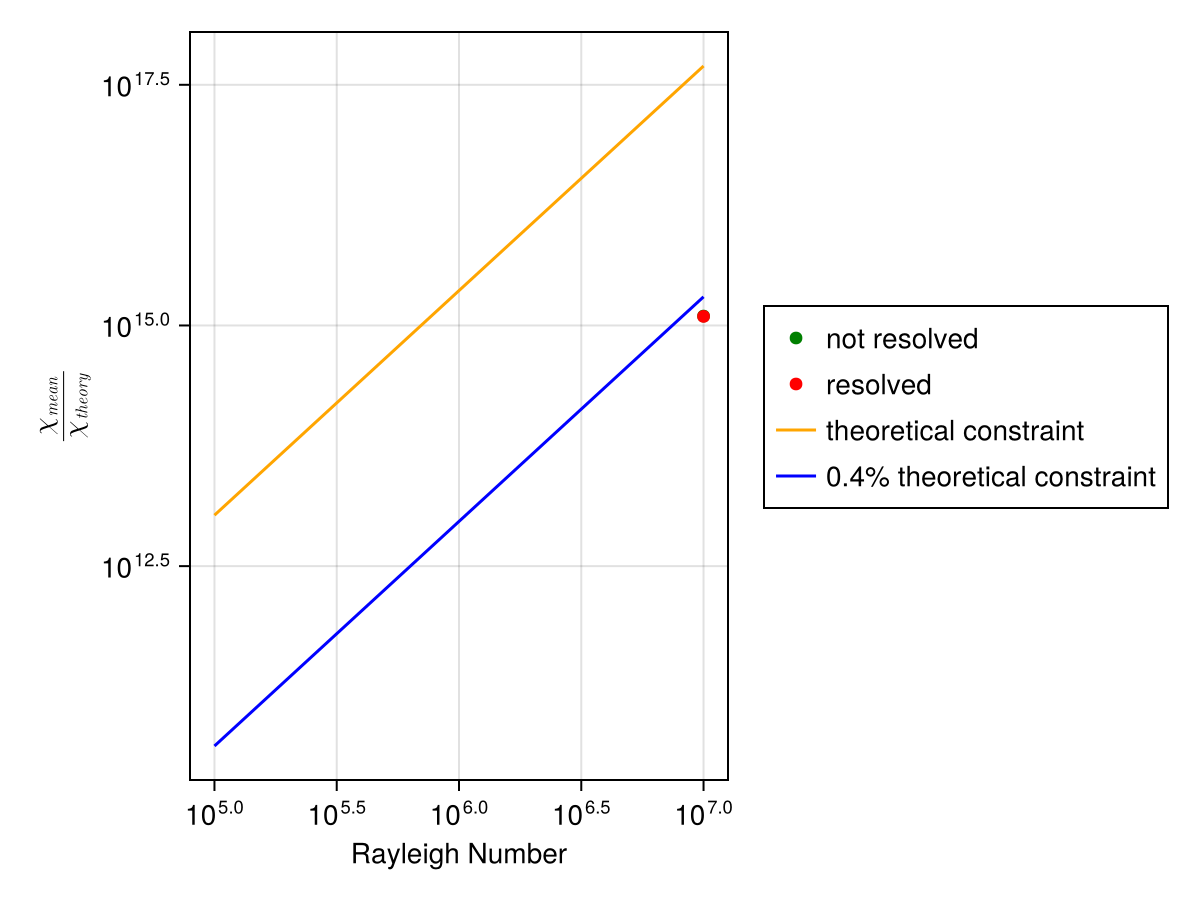

In [62]:
f_χ = Figure()
ax = Axis(f_χ[1,1], 
            xscale = log10,
            yscale = log10, 
            xlabel = "Rayleigh Number",
            ylabel = L"\frac{\chi_{mean}}{\chi_{theory}}"
)

scatter!(ax, 1e7, χ_means[1], label="not resolved", color= :green)
scatter!(ax, 1e7, χ_means[2], color = :red, label="resolved")
lines!(ax, Ras, χ_theories_from_brain, color = :orange, label="theoretical constraint")
lines!(ax, Ras, χ_theories_from_brain * 0.004, color = :blue, label="0.4% theoretical constraint")
Legend(f_χ[1,2], ax)

f_χ